## Index Fund Sim with Payoff Choice

In [1]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, InvestmentModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel, LoanModelResult
from quant_slc_hedging.strategies.base_strategy import Strategy
from quant_slc_hedging.strategies.min_repayment import MinRepaymentStrategy
from quant_slc_hedging.strategies.fixed_pct_repayment import FixedPctRepaymentStrategy
from quant_slc_hedging.strategies.index_fund import IndexFundStrategy
from quant_slc_hedging.simulation import SimulationHandler
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from typing import List, Union
from dataclasses import dataclass

In [2]:
n_paths = 10_000
years_remaining = 25
observations = years_remaining * 12
seed = 1234
starting_salary = 50_000
initial_loan = 40_000
initial_investment_balance = 10_000
salary_growth = SalaryGrowthType(growth_type="Medium")
salary_config=SalaryModelInputs(
    starting_salary=starting_salary,
    salary_growth_dist=salary_growth
    )
loan_config = LoanModelInputs(
    initial_loan_balance=initial_loan,
    remaining_loan_term_months=12*years_remaining
)
investment_config = InvestmentModelInputs(
    initial_investment_balance=initial_investment_balance,
    annual_expected_return=0.05,
    annual_vol=0.04,
    payoff_loan_with_investments=True
)
salary_rng = np.random.default_rng(seed)
investment_rng = np.random.default_rng(seed + 1) 
strategy = IndexFundStrategy(investment_config=investment_config, investment_pct=0.05, repayment_pct=0.05, repayment_threshold=loan_config.repayment_threshold, rng_gen=investment_rng, n_paths=n_paths, n_obs=observations)
sim = SimulationHandler(salary_config=salary_config, loan_config=loan_config, investment_config=investment_config, strategy=strategy, n_paths=n_paths, observations=observations, salary_rng=salary_rng)
res = sim.run_simulation()
print("done")

Sim finished
done


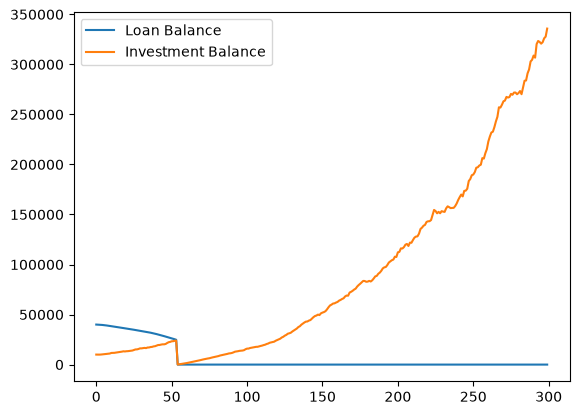

In [3]:
path = 1234

fig, ax = plt.subplots()

ax.plot(
    res.loan_result.loan_balance[path],
    label="Loan Balance",
)

ax.plot(
    res.investment_balance[path],
    label="Investment Balance",
)

ax.legend()

In [6]:
res.loan_result.loan_balance[:, -1].mean()

np.float64(90.97800005578266)